In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set paths
dataset_folder = 'Dataset/'
normal_folder = 'Dataset/NormalClass/'

# Extract all zipped files from attacks
# print("Extracting attack dataset files...")
# for file in os.listdir(dataset_folder):
#     if file.endswith('.zip') and 'NormalClass' not in file:
#         zip_path = os.path.join(dataset_folder, file)
#         with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#             zip_ref.extractall(dataset_folder)
#         print(f"  ✓ Extracted {file}")

# Extract all zipped files from normal class
print("\nExtracting normal class dataset files...")
if os.path.exists(normal_folder):
    for file in os.listdir(normal_folder):
        if file.endswith('.zip'):
            zip_path = os.path.join(normal_folder, file)
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(normal_folder)
            print(f"  ✓ Extracted {file}")

print("\n✓ All files extracted")


Extracting normal class dataset files...
  ✓ Extracted Distance.csv.zip
  ✓ Extracted Flame_Sensor.csv.zip
  ✓ Extracted Heart_Rate.csv.zip
  ✓ Extracted IR_Receiver.csv.zip
  ✓ Extracted Modbus.csv.zip

✓ All files extracted


## 2. Load and Combine Attack Datasets

In [11]:
# Load all attack CSVs
print("Loading attack datasets...")
dfs = []

for file in sorted(os.listdir(dataset_folder)):
    if file.endswith('.csv') and 'NormalClass' not in file:
        file_path = os.path.join(dataset_folder, file)
        try:
            # Get attack type from filename
            attack_type = file.replace('.csv', '').replace('_attack', '').replace('DDoS_', 'DDoS_')
            
            df_temp = pd.read_csv(file_path)
            
            # Get a handful of sequential data (first 1000 rows per attack)
            df_temp = df_temp.head(1000)
            if 'frame.time' in df_temp.columns:
                df_temp['frame.time'] = pd.to_datetime(df_temp['frame.time'], errors='coerce')
                df_temp = df_temp.dropna(subset=['frame.time'])
                
                # remove invalid years
                df_temp = df_temp[
                    (df_temp['frame.time'].dt.year >= 2000) &
                    (df_temp['frame.time'].dt.year <= 2030)
                ]

            # THEN sample
            df_temp = df_temp.head(1000)

            # Add attack type column if missing
            if 'Attack_type' not in df_temp.columns:
                df_temp['Attack_type'] = attack_type
            
            
            # Sort by IP and time
            if 'ip.src_host' in df_temp.columns and 'frame.time' in df_temp.columns:
                df_temp = df_temp.sort_values(['ip.src_host', 'frame.time']).reset_index(drop=True)
            
            dfs.append(df_temp)
            print(f"  ✓ {file:40s} - {len(df_temp):6d} rows")
        except Exception as e:
            print(f"  ✗ {file:40s} - Error: {str(e)}")

# Load normal class data (10,000 rows)
print("\nLoading normal class datasets...")
normal_folder = 'Dataset/NormalClass/'
if os.path.exists(normal_folder):
    normal_dfs = []
    for file in sorted(os.listdir(normal_folder)):
        if file.endswith('.csv'):
            file_path = os.path.join(normal_folder, file)
            try:
                df_temp = pd.read_csv(file_path)
                
                # Get a portion of normal data (enough to reach 10,000 total across all normal files)
                df_temp = df_temp.head(2000)  # ~2000 per file for multiple files
                
                # Add attack type as 'Normal'
                df_temp['Attack_type'] = 'Normal'
                
                # Ensure frame.time is parsed as datetime
                if 'frame.time' in df_temp.columns:
                    df_temp['frame.time'] = pd.to_datetime(df_temp['frame.time'], errors='coerce')
                
                # Sort by IP and time
                if 'ip.src_host' in df_temp.columns and 'frame.time' in df_temp.columns:
                    df_temp = df_temp.sort_values(['ip.src_host', 'frame.time']).reset_index(drop=True)
                
                normal_dfs.append(df_temp)
                print(f"  ✓ {file:40s} - {len(df_temp):6d} rows")
            except Exception as e:
                print(f"  ✗ {file:40s} - Error: {str(e)}")
    
    if normal_dfs:
        df_normal = pd.concat(normal_dfs, axis=0, ignore_index=True).head(10000)
        dfs.append(df_normal)
        print(f"\n  ✓ Normal class combined - {len(df_normal):6d} rows (total from {len(normal_dfs)} files)")

print(f"\nCombining {len(dfs)} datasets into one sorted time series...")
df_combined = pd.concat(dfs, axis=0, ignore_index=True)

# Final sort by IP and time
if 'ip.src_host' in df_combined.columns and 'frame.time' in df_combined.columns:
    df_combined = df_combined.sort_values(['ip.src_host', 'frame.time']).reset_index(drop=True)

print(f"Combined dataset shape: {df_combined.shape}")
print(f"\nAttack types in dataset:")
print(df_combined['Attack_type'].value_counts())

Loading attack datasets...
  ✓ Backdoor_attack.csv                      -   1000 rows
  ✓ DDoS_HTTP_Flood_attack.csv               -   1000 rows
  ✓ DDoS_ICMP_Flood_attack.csv               -   1000 rows
  ✓ DDoS_TCP_SYN_Flood_attack.csv            -   1000 rows
  ✓ DDoS_UDP_Flood_attack.csv                -      0 rows
  ✓ MITM_attack.csv                          -      0 rows
  ✓ OS_Fingerprinting_attack.csv             -   1000 rows
  ✓ Password_attack.csv                      -   1000 rows
  ✓ Port_Scanning_attack.csv                 -   1000 rows
  ✓ Ransomware_attack.csv                    -   1000 rows
  ✓ SQL_injection_attack.csv                 -   1000 rows
  ✓ Uploading_attack.csv                     -   1000 rows
  ✓ Vulnerability_scanner_attack.csv         -   1000 rows
  ✓ XSS_attack.csv                           -   1000 rows

Loading normal class datasets...
  ✓ Distance.csv                             -   2000 rows
  ✓ Flame_Sensor.csv                         -   2000 

## 3. Data Preprocessing (Following Notebook Procedure)

In [22]:
# Remove duplicates
print(f"Removing duplicates...")
print(f"Before: {len(df_combined)} rows")
df_combined.drop_duplicates(subset=None, keep='first', inplace=True)
print(f"After: {len(df_combined)} rows")

# Drop columns with fixed values and problematic columns
drop_columns = [
    'ip.dst_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4',
    'http.file_data', 'http.request.full_uri', 'icmp.transmit_timestamp',
    'http.request.uri.query', 'tcp.options', 'tcp.payload', 'udp.port', 'mqtt.msg', 'http.referer', 'http.request.version', 'tcp.dstport', 'dns.qry.name', 'mqtt.topic', 'mqtt.protoname',
]

drop_columns = [col for col in drop_columns if col in df_combined.columns]
df_combined.drop(columns=drop_columns, inplace=True)

print(f"Dropped columns: {len(drop_columns)}")

Removing duplicates...
Before: 21815 rows
After: 21815 rows
Dropped columns: 6


In [23]:
# Identify columns with single unique value
print("Removing columns with single unique value...")
single_value_cols = []
for col in df_combined.columns:
    if df_combined[col].nunique() == 1 and col not in ['Attack_type', 'Attack_label']:
        single_value_cols.append(col)

if single_value_cols:
    df_combined.drop(columns=single_value_cols, inplace=True)
    print(f"Dropped {len(single_value_cols)} single-value columns")
else:
    print("No single-value columns found")

Removing columns with single unique value...
No single-value columns found


In [25]:
numeric_cols = [
    'icmp.checksum',
    'icmp.seq_le',
    'tcp.ack_raw',
    'tcp.checksum',
    'tcp.connection.fin',
    'tcp.flags',
    'tcp.len',
    'tcp.srcport',
    'mqtt.conack.flags',
    'mqtt.conflags',
    'mqtt.hdrflags'
]

# Convert to numeric (invalid → NaN)
df_combined[numeric_cols] = df_combined[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows where ANY of these columns is not numeric
df_combined = df_combined.dropna(subset=numeric_cols)

In [29]:
# Identify categorical and numerical columns
print("\nIdentifying column types...")
categorical_cols = df_combined.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_combined.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove columns that shouldn't be encoded
if 'frame.time' in categorical_cols:
    categorical_cols.remove('frame.time')
if 'ip.src_host' in categorical_cols:
    categorical_cols.remove('ip.src_host')
if 'Attack_type' in categorical_cols:
    categorical_cols.remove('Attack_type')
if 'Attack_label' in categorical_cols:
    categorical_cols.remove('Attack_label')

print(f"Categorical columns: {len(categorical_cols)}")
for col in categorical_cols[:5]:  # Show first 5
    print(f"  • {col}: {df_combined[col].nunique()} unique values")


Identifying column types...
Categorical columns: 1
  • http.request.method: 2 unique values


In [30]:
# One-hot encode categorical columns
print("\nOne-hot encoding categorical columns...")
for col in categorical_cols:
    dummies = pd.get_dummies(df_combined[col], prefix=col)
    df_combined = pd.concat([df_combined, dummies], axis=1)
    df_combined.drop(col, axis=1, inplace=True)
    print(f"  ✓ Encoded: {col}")

print(f"\nTotal columns after encoding: {df_combined.shape[1]}")


One-hot encoding categorical columns...
  ✓ Encoded: http.request.method

Total columns after encoding: 40


In [31]:
# Sort by source IP and time (for time series)
print("Sorting data by IP and time...")
df_combined['frame.time'] = pd.to_datetime(df_combined['frame.time'], errors='coerce')
df_combined = df_combined.sort_values(['ip.src_host', 'frame.time']).reset_index(drop=True)

print(f"Dataset shape: {df_combined.shape}")
print(f"Date range: {df_combined['frame.time'].min()} to {df_combined['frame.time'].max()}")

Sorting data by IP and time...
Dataset shape: (1600, 40)
Date range: 2021-01-01 02:39:58.091130 to 2022-01-01 00:48:15.953530


In [32]:
# Define feature columns (exclude temporal and meta columns)
exclude_cols = ['frame.time', 'ip.src_host', 'Attack_type', 'Attack_label']
feature_cols = [col for col in df_combined.columns if col not in exclude_cols]

print(f"Feature columns for scaling: {len(feature_cols)}")
print(f"\nFirst 10 feature columns:")
for col in feature_cols[:10]:
    print(f"  • {col}")

Feature columns for scaling: 36

First 10 feature columns:
  • arp.opcode
  • arp.hw.size
  • icmp.checksum
  • icmp.seq_le
  • http.content_length
  • http.response
  • http.tls_port
  • tcp.ack
  • tcp.ack_raw
  • tcp.checksum


In [33]:
# Scale features
print("Scaling features...")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_features = df_combined[feature_cols].astype('float32')
df_features_scaled = scaler.fit_transform(df_features)

# Create scaled dataframe
df_scaled = pd.DataFrame(df_features_scaled, columns=feature_cols)
df_scaled['ip.src_host'] = df_combined['ip.src_host'].values
df_scaled['frame.time'] = df_combined['frame.time'].values
df_scaled['Attack_type'] = df_combined['Attack_type'].values

print("✓ Features scaled using StandardScaler")
print(f"Scaled dataset shape: {df_scaled.shape}")

Scaling features...
✓ Features scaled using StandardScaler
Scaled dataset shape: (1600, 39)


## Exploratory Data Analysis (EDA) & Visualizations

=== Attack Type Distribution ===

Attack_type
Normal                   1133
OS_Fingerprinting         149
Ransomware                138
Port_Scanning             101
XSS                        45
Backdoor                   25
DDoS_TCP                    3
Vulnerability_scanner       3
SQL_injection               2
Uploading                   1
Name: count, dtype: int64


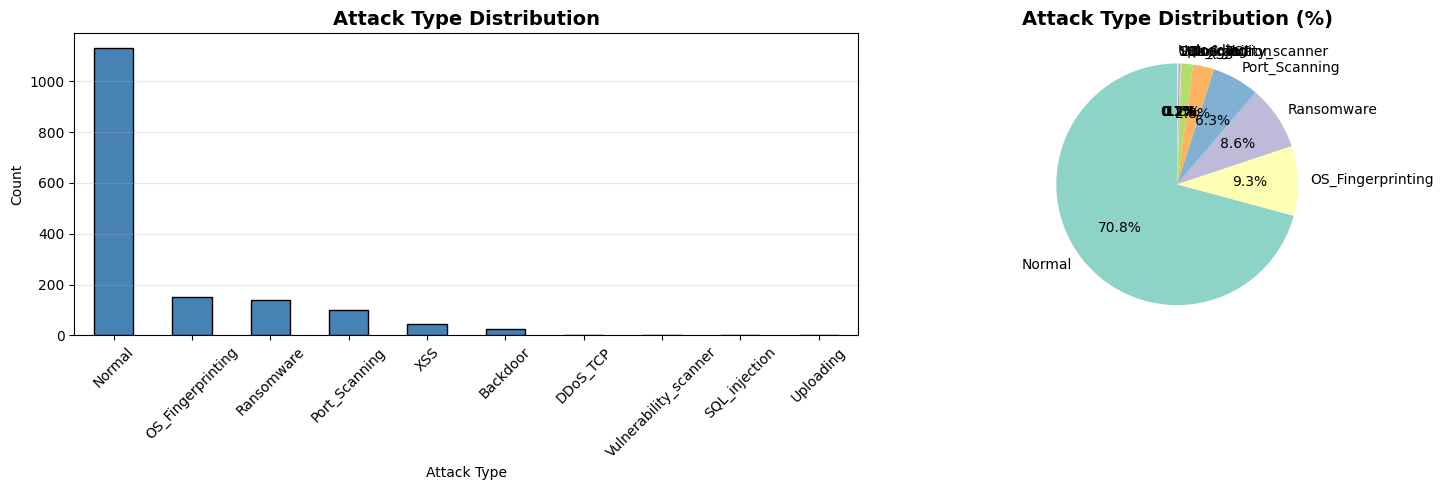


Total samples: 1600
Attack types: 10


In [34]:
# 1. Attack Type Distribution
print("=== Attack Type Distribution ===\n")
attack_counts = df_combined['Attack_type'].value_counts()
print(attack_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
attack_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Attack Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(attack_counts)))
axes[1].pie(attack_counts.values, labels=attack_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Attack Type Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal samples: {len(df_combined)}")
print(f"Attack types: {len(attack_counts)}")

=== Feature Statistics ===

Basic statistics of features:
                        count          mean       std       min       25%  \
arp.opcode             1600.0 -1.907349e-08  1.000313 -0.393794 -0.393794   
arp.hw.size            1600.0 -5.722046e-08  1.000313 -0.419054 -0.419054   
icmp.checksum          1600.0  0.000000e+00  0.000000  0.000000  0.000000   
icmp.seq_le            1600.0  0.000000e+00  0.000000  0.000000  0.000000   
http.content_length    1600.0  0.000000e+00  0.000000  0.000000  0.000000   
http.response          1600.0  0.000000e+00  0.000000  0.000000  0.000000   
http.tls_port          1600.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.ack                1600.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.ack_raw            1600.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.checksum           1600.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.connection.fin     1600.0  0.000000e+00  0.000000  0.000000  0.000000   
tcp.connection.rst

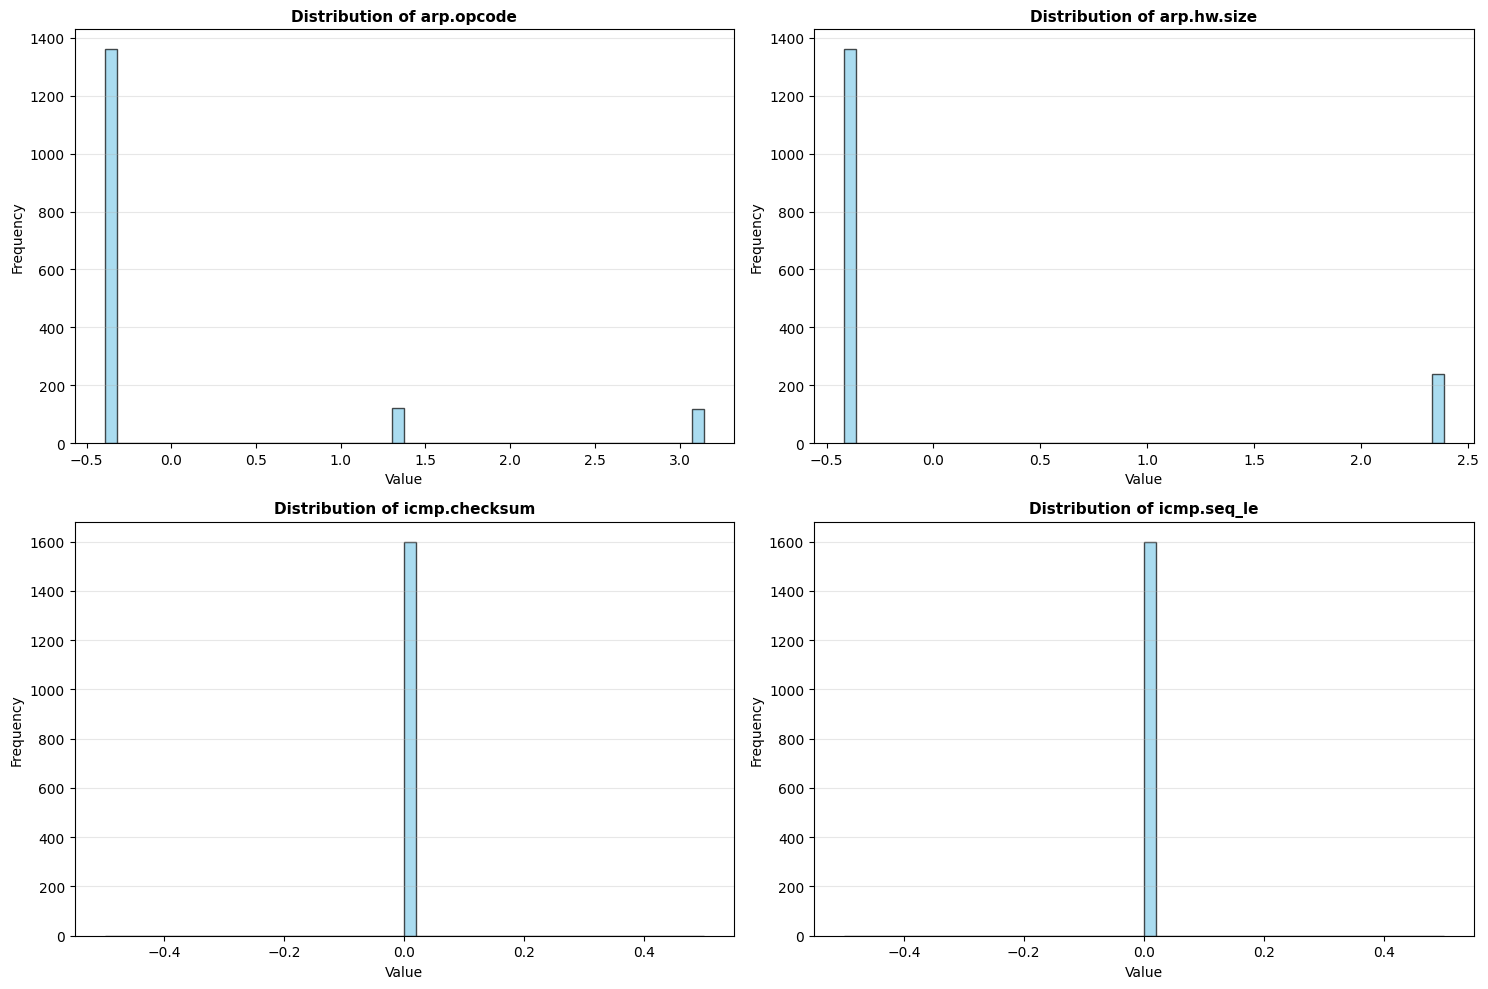


Total features (after encoding): 36


In [35]:
# 2. Feature Statistics
print("=== Feature Statistics ===\n")
print("Basic statistics of features:")
print(df_scaled[feature_cols].describe().T.head(15))  # Show first 15 features

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of first 4 features
for idx, col in enumerate(feature_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df_scaled[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal features (after encoding): {len(feature_cols)}")

=== Feature Correlation Analysis ===



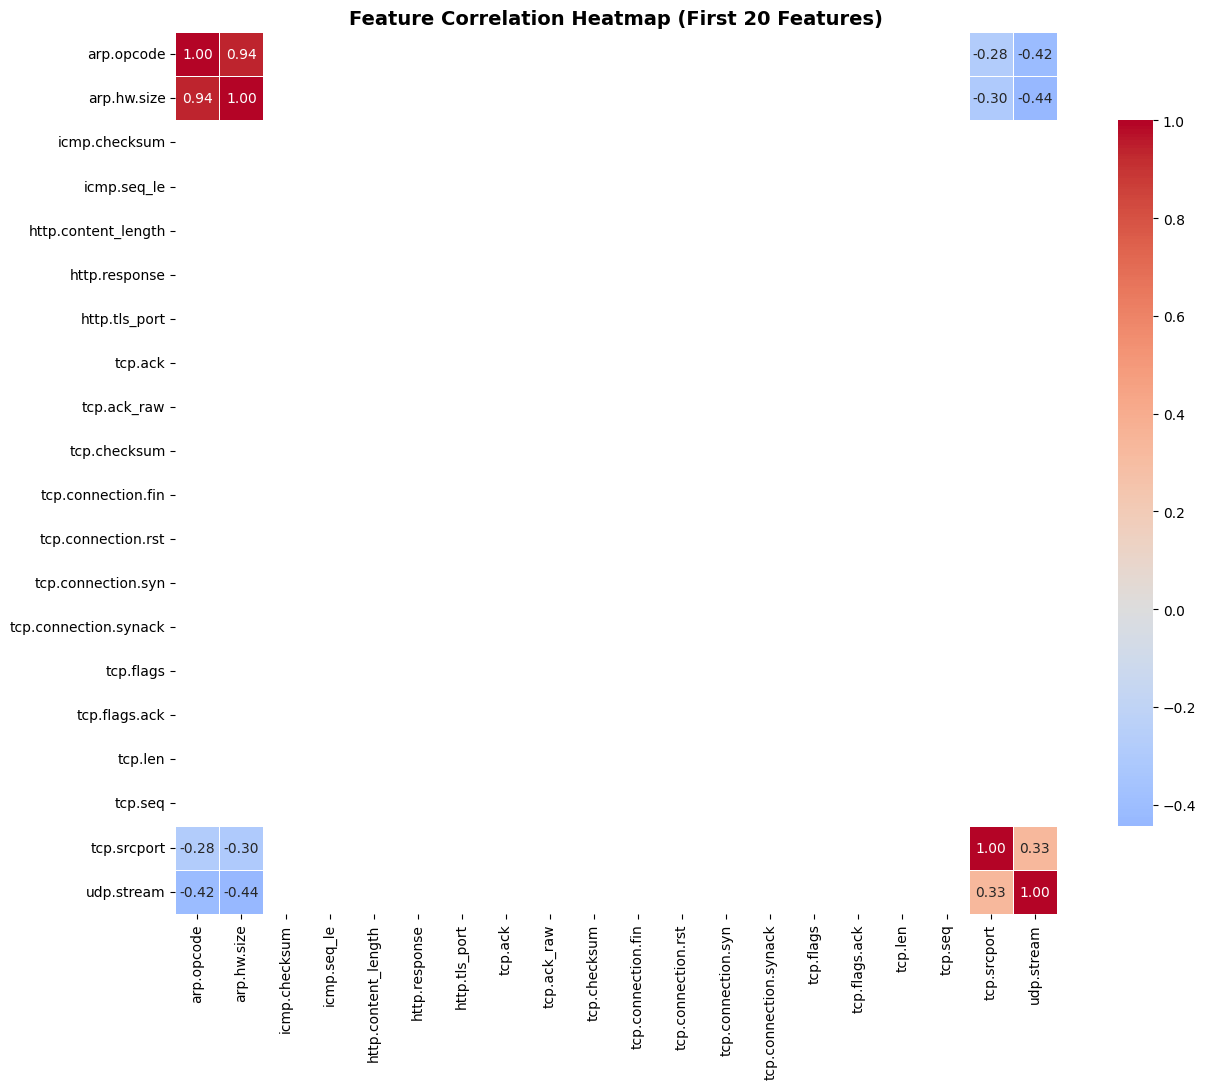

Top 10 feature correlations:
  1. arp.opcode <-> arp.hw.size: 0.9397
  2. arp.opcode <-> icmp.checksum: nan
  3. arp.opcode <-> icmp.seq_le: nan
  4. arp.opcode <-> http.content_length: nan
  5. arp.opcode <-> http.response: nan
  6. arp.opcode <-> http.tls_port: nan
  7. arp.opcode <-> tcp.ack: nan
  8. arp.opcode <-> tcp.ack_raw: nan
  9. arp.opcode <-> tcp.checksum: nan
  10. arp.opcode <-> tcp.connection.fin: nan


In [36]:
# 3. Correlation Heatmap
print("=== Feature Correlation Analysis ===\n")

# Calculate correlation for first 20 features to avoid overcrowding
corr_cols = feature_cols[:20]
correlation_matrix = df_scaled[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap (First 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highest correlations
print("Top 10 feature correlations:")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], 
                          abs(correlation_matrix.iloc[i, j])))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
for i, (feat1, feat2, corr) in enumerate(corr_pairs[:10]):
    print(f"  {i+1}. {feat1} <-> {feat2}: {corr:.4f}")

=== Feature Distribution by Attack Type ===



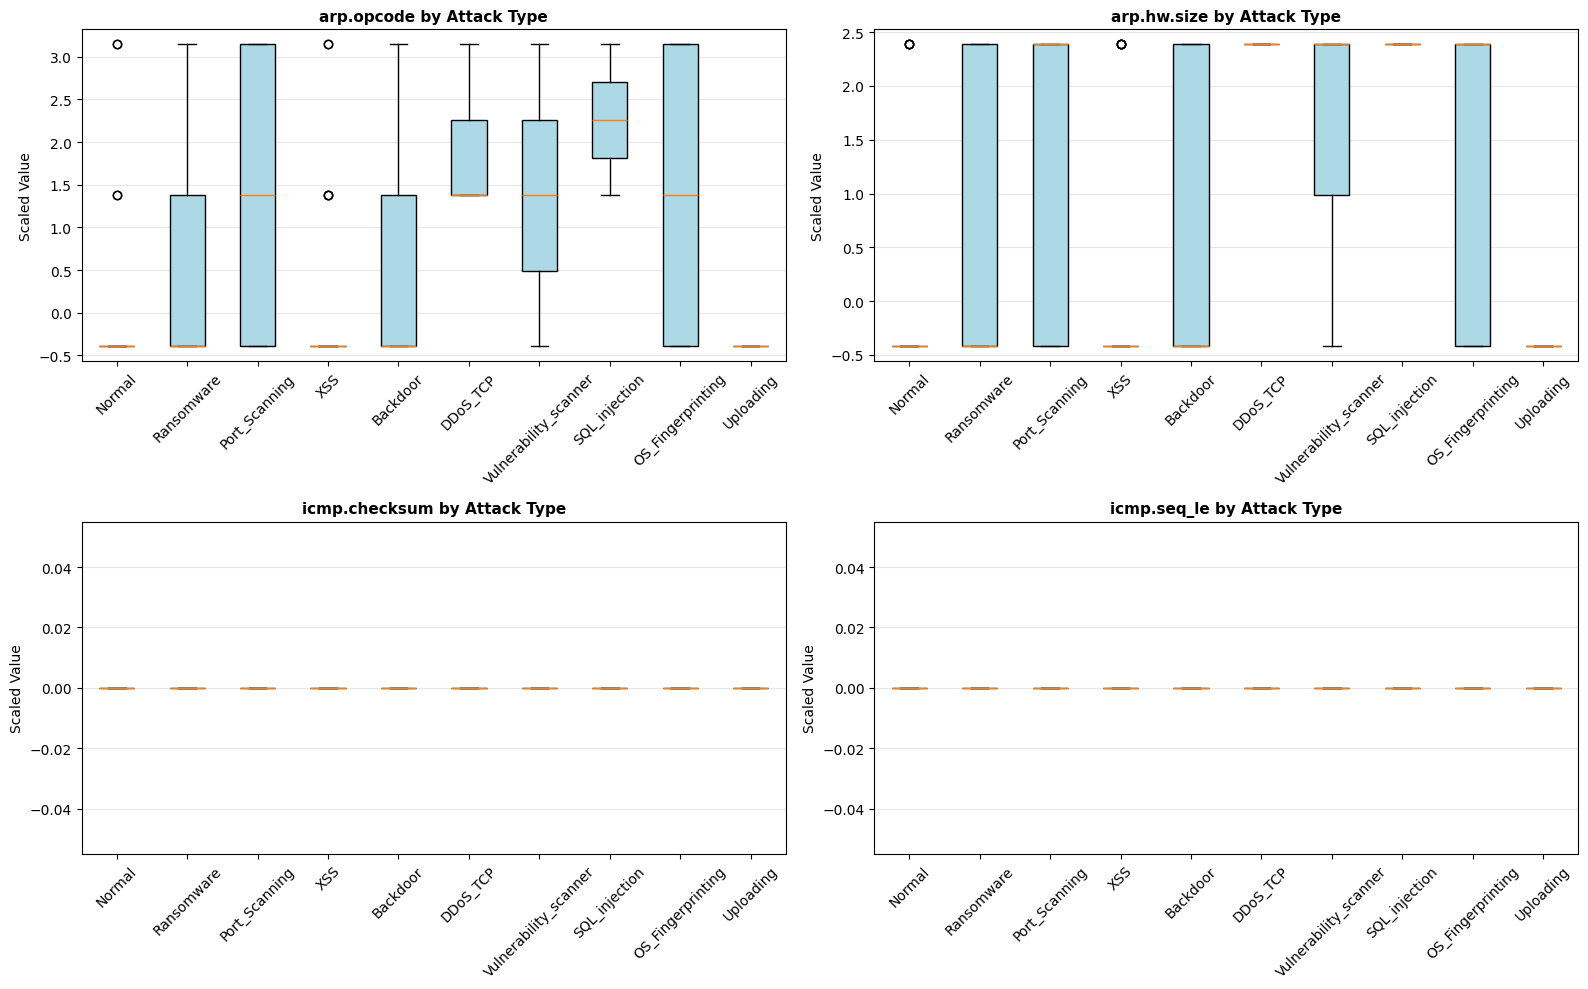

Box plots show feature distributions across different attack types


In [37]:
# 4. Attack Type Feature Comparison (Box plots)
print("=== Feature Distribution by Attack Type ===\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Select 4 features for comparison
compare_features = feature_cols[:4]

for idx, feature in enumerate(compare_features):
    ax = axes[idx // 2, idx % 2]
    
    # Create box plot for each attack type
    data_for_plot = [df_scaled[df_scaled['Attack_type'] == attack][feature].values 
                     for attack in df_combined['Attack_type'].unique()]
    
    bp = ax.boxplot(data_for_plot, labels=df_combined['Attack_type'].unique(), patch_artist=True)
    
    # Color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax.set_title(f'{feature} by Attack Type', fontsize=11, fontweight='bold')
    ax.set_ylabel('Scaled Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Box plots show feature distributions across different attack types")

=== Time Series Patterns ===



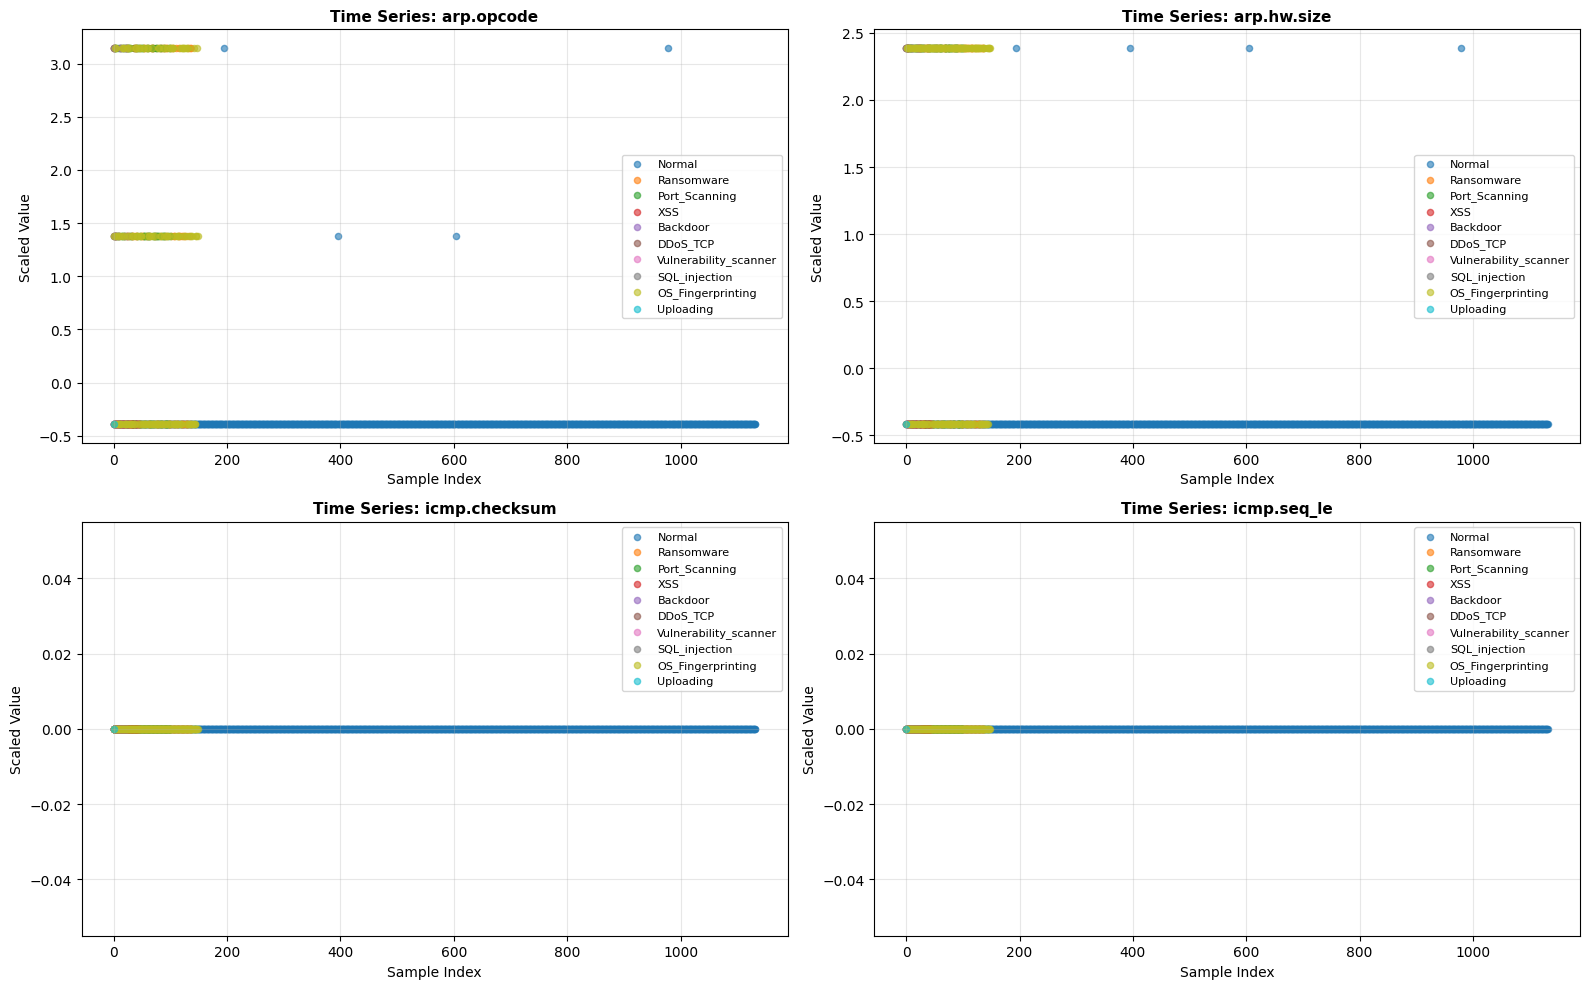

Time series patterns show how features vary across different attack types


In [38]:
# 5. Time Series Patterns - Feature values over time
print("=== Time Series Patterns ===\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot first feature values over time colored by attack type
for idx, feature in enumerate(feature_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    
    # Sample data for visualization (to avoid overcrowding)
    sample_df = df_scaled.sample(n=min(5000, len(df_scaled)), random_state=42)
    
    # Plot scatter for each attack type
    for attack_type in df_combined['Attack_type'].unique():
        attack_data = sample_df[sample_df['Attack_type'] == attack_type]
        ax.scatter(range(len(attack_data)), attack_data[feature], 
                  label=attack_type, alpha=0.6, s=20)
    
    ax.set_title(f'Time Series: {feature}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Scaled Value')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Time series patterns show how features vary across different attack types")

=== Mean Feature Values by Attack Type ===



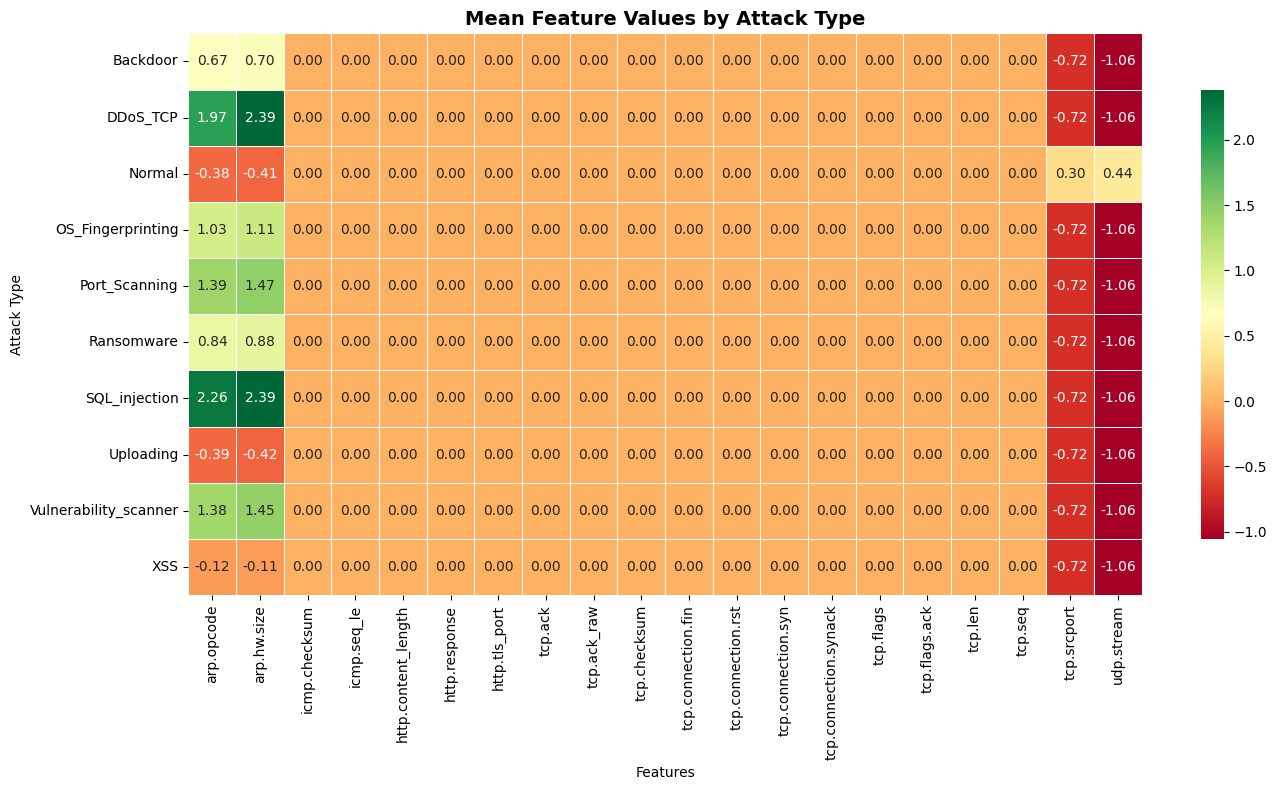


Mean values show characteristic patterns of each attack type


In [39]:
# 6. Attack Type Mean Features Heatmap
print("=== Mean Feature Values by Attack Type ===\n")

# Calculate mean features for each attack type (using first 20 features)
heatmap_features = feature_cols[:20]
mean_features = df_scaled.groupby('Attack_type')[heatmap_features].mean()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(mean_features, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={"shrink": 0.8}, linewidths=0.5, ax=ax)
ax.set_title('Mean Feature Values by Attack Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Attack Type')
plt.tight_layout()
plt.show()

print("\nMean values show characteristic patterns of each attack type")

=== Source IP Analysis ===

IP and Packet Statistics by Attack Type:
                       Unique_IPs  Total_Packets
Attack_type                                     
Backdoor                        3             25
DDoS_TCP                        1              3
Normal                          8              9
OS_Fingerprinting               3            149
Port_Scanning                   3            101
Ransomware                      3            138
SQL_injection                   1              2
Uploading                       1              1
Vulnerability_scanner           1              3
XSS                             3             45


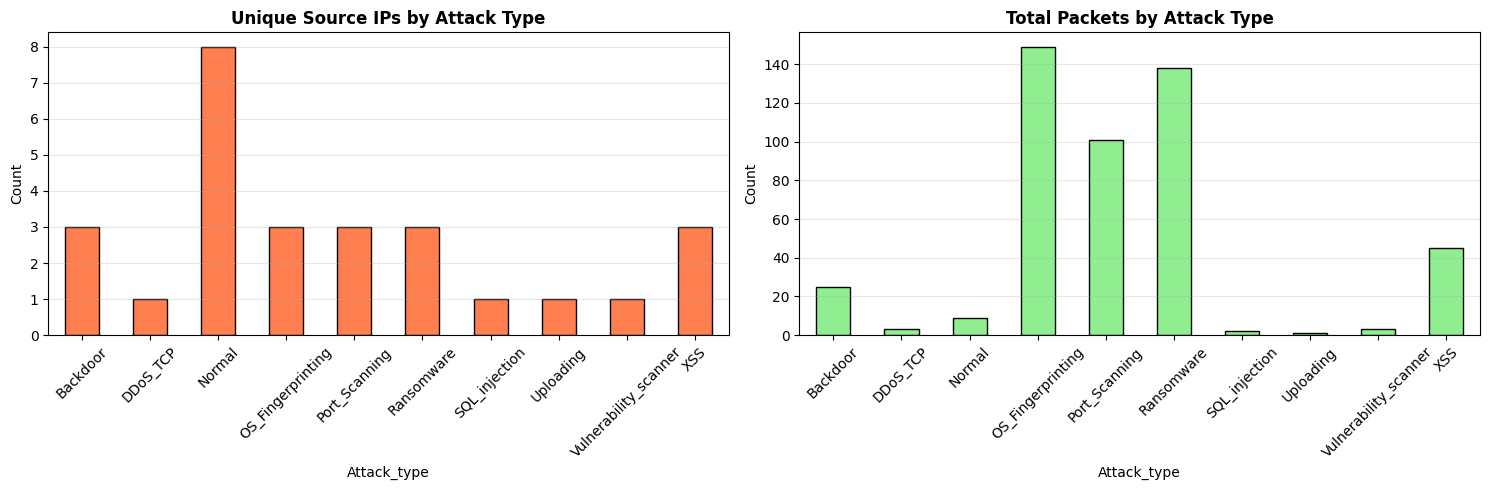


Top IPs per Attack Type:

Normal:
  192.168.0.1: 560 packets
  192.168.0.128: 559 packets
  0: 9 packets

Ransomware:
  0: 119 packets
  192.168.0.128: 12 packets
  0.0.0.0: 7 packets

Port_Scanning:
  0: 95 packets
  0.0.0.0: 3 packets
  192.168.0.128: 3 packets

XSS:
  0: 34 packets
  192.168.0.128: 8 packets
  0.0.0.0: 3 packets

Backdoor:
  0: 20 packets
  192.168.0.128: 4 packets
  0.0.0.0: 1 packets

DDoS_TCP:
  0: 3 packets

Vulnerability_scanner:
  0: 3 packets

SQL_injection:
  0: 2 packets

OS_Fingerprinting:
  0: 131 packets
  192.168.0.128: 12 packets
  0.0.0.0: 6 packets

Uploading:
  0: 1 packets


In [40]:
# 7. Source IP Analysis
print("=== Source IP Analysis ===\n")

# Group by attack type and get unique IPs and packet counts
ip_analysis = df_combined.groupby('Attack_type').agg({
    'ip.src_host': 'nunique',
    'frame.time': 'count'
}).rename(columns={'ip.src_host': 'Unique_IPs', 'frame.time': 'Total_Packets'})

print("IP and Packet Statistics by Attack Type:")
print(ip_analysis)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Unique IPs per attack type
ip_analysis['Unique_IPs'].plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Unique Source IPs by Attack Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Packets per attack type
ip_analysis['Total_Packets'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Total Packets by Attack Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show top IPs per attack type
print("\nTop IPs per Attack Type:")
for attack_type in df_combined['Attack_type'].unique():
    attack_ips = df_combined[df_combined['Attack_type'] == attack_type]['ip.src_host'].value_counts().head(3)
    print(f"\n{attack_type}:")
    for ip, count in attack_ips.items():
        print(f"  {ip}: {count} packets")

In [41]:
# 8. Data Summary & Insights
print("=== Data Summary & Key Insights ===\n")

print(f"Total Records: {len(df_combined):,}")
print(f"Total Unique IPs: {df_combined['ip.src_host'].nunique()}")
print(f"Time Range: {df_combined['frame.time'].min()} to {df_combined['frame.time'].max()}")
print(f"Total Features: {len(feature_cols)}")
print(f"\nAttack Type Distribution:")
for attack, count in df_combined['Attack_type'].value_counts().items():
    pct = (count / len(df_combined)) * 100
    print(f"  • {attack:30s}: {count:6,} ({pct:5.1f}%)")

# Data quality metrics
print(f"\nData Quality:")
print(f"  • Missing values in frame.time: {df_combined['frame.time'].isna().sum()}")
print(f"  • Missing values in ip.src_host: {df_combined['ip.src_host'].isna().sum()}")
print(f"  • Duplicate rows: {df_combined.duplicated().sum()}")

# Feature statistics
print(f"\nFeature Statistics (scaled):")
print(f"  • Mean: {df_scaled[feature_cols].mean().mean():.4f}")
print(f"  • Std: {df_scaled[feature_cols].std().mean():.4f}")
print(f"  • Min: {df_scaled[feature_cols].min().min():.4f}")
print(f"  • Max: {df_scaled[feature_cols].max().max():.4f}")

=== Data Summary & Key Insights ===

Total Records: 1,600
Total Unique IPs: 8
Time Range: 2021-01-01 02:39:58.091130 to 2022-01-01 00:48:15.953530
Total Features: 36

Attack Type Distribution:
  • Normal                        :  1,133 ( 70.8%)
  • OS_Fingerprinting             :    149 (  9.3%)
  • Ransomware                    :    138 (  8.6%)
  • Port_Scanning                 :    101 (  6.3%)
  • XSS                           :     45 (  2.8%)
  • Backdoor                      :     25 (  1.6%)
  • DDoS_TCP                      :      3 (  0.2%)
  • Vulnerability_scanner         :      3 (  0.2%)
  • SQL_injection                 :      2 (  0.1%)
  • Uploading                     :      1 (  0.1%)

Data Quality:
  • Missing values in frame.time: 1124
  • Missing values in ip.src_host: 0
  • Duplicate rows: 0

Feature Statistics (scaled):
  • Mean: 0.0000
  • Std: 0.2501
  • Min: -5.5111
  • Max: 11.1252


## 4. Create Time Series Sequences

In [42]:
# Create sequences from time series data
print("Creating time series sequences...")

SEQ_LEN = 10  # Sequence length

def create_sequences(df, feature_cols, seq_len=10):
    X_seq, y_seq = [], []
    
    for ip, group in df.groupby('ip.src_host'):
        group = group.sort_values('frame.time')
        
        X = group[feature_cols].values
        y = group['Attack_type'].values
        
        # Create sequences
        for i in range(len(group) - seq_len):
            X_seq.append(X[i:i+seq_len])
            y_seq.append(y[i+seq_len])
    
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(df_scaled, feature_cols, seq_len=SEQ_LEN)

print(f"✓ Sequences created")
print(f"  X shape: {X_seq.shape} (samples, sequence_length, features)")
print(f"  y shape: {y_seq.shape} (samples,)")
print(f"\nAttack type distribution:")
for attack_type, count in pd.Series(y_seq).value_counts().items():
    print(f"  • {attack_type}: {count} sequences")

Creating time series sequences...
✓ Sequences created
  X shape: (1556, 10, 36) (samples, sequence_length, features)
  y shape: (1556,) (samples,)

Attack type distribution:
  • Normal: 1117 sequences
  • OS_Fingerprinting: 149 sequences
  • Ransomware: 116 sequences
  • Port_Scanning: 95 sequences
  • XSS: 45 sequences
  • Backdoor: 25 sequences
  • DDoS_TCP: 3 sequences
  • Vulnerability_scanner: 3 sequences
  • SQL_injection: 2 sequences
  • Uploading: 1 sequences


## 5. Prepare Data for LSTM

In [43]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

print("Encoding labels...")

# Encode attack types
le = LabelEncoder()
y_encoded = le.fit_transform(y_seq)
num_classes = len(le.classes_)

print(f"Number of attack classes: {num_classes}")
print(f"\nClass mapping:")
for idx, label in enumerate(le.classes_):
    print(f"  {idx}: {label}")

# Convert to categorical
y_cat = to_categorical(y_encoded, num_classes=num_classes)

print(f"\nCategorical labels shape: {y_cat.shape}")

Encoding labels...
Number of attack classes: 10

Class mapping:
  0: Backdoor
  1: DDoS_TCP
  2: Normal
  3: OS_Fingerprinting
  4: Port_Scanning
  5: Ransomware
  6: SQL_injection
  7: Uploading
  8: Vulnerability_scanner
  9: XSS

Categorical labels shape: (1556, 10)


In [ ]:
# Split data into train and test sets (80-20 split)
print("Splitting data into train and test sets...")

split_ratio = 0.8
split_index = int(len(X_seq) * split_ratio)

X_train = X_seq[:split_index]
X_test = X_seq[split_index:]
y_train = y_cat[:split_index]
y_test = y_cat[split_index:]

print(f"Train set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set:  X_test {X_test.shape}, y_test {y_test.shape}")

## 6. Build and Train LSTM Model

In [ ]:
# Import Keras/TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Building LSTM model...")

timesteps = X_train.shape[1]  # Sequence length
features = X_train.shape[2]   # Number of features

model = Sequential()

# LSTM Layer 1
model.add(LSTM(64, return_sequences=True, input_shape=(timesteps, features)))
model.add(Dropout(0.3))

# LSTM Layer 2
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.3))

# Dense Layers
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
model.summary()

In [ ]:
# Define callbacks
print("Setting up callbacks...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("✓ Callbacks configured")

In [ ]:
# Train model
print("Training LSTM model...\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✓ Model training completed")

## 7. Evaluate Model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Evaluating model...\n")

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

In [ ]:
# Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - LSTM Attack Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. Plot Training History

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 9. Save Model

In [ ]:
# Save model and scaler
import pickle

print("Saving model and artifacts...")

# Save model
model.save('lstm_attack_detection_model.h5')
print("✓ Model saved as 'lstm_attack_detection_model.h5'")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved as 'scaler.pkl'")

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✓ Label encoder saved as 'label_encoder.pkl'")

print("\n✓ All artifacts saved successfully!")